<a href="https://colab.research.google.com/github/PawaniMekhala/19APC4067-StringManipulationService/blob/main/04_advanced_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Setup & Load Data
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/student-dropout-prediction"

X_train = pd.read_csv(f"{PROJECT_ROOT}/data/processed/X_train.csv")
y_train = pd.read_csv(f"{PROJECT_ROOT}/data/processed/y_train.csv").values.ravel()

X_test = pd.read_csv(f"{PROJECT_ROOT}/data/processed/X_test.csv")
y_test = pd.read_csv(f"{PROJECT_ROOT}/data/processed/y_test.csv").values.ravel()

# Install XGBoost
!pip install xgboost

Mounted at /content/drive


In [ ]:
# Train Random Forest
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_dist = {
    'n_estimators': [200, 300],
    'max_depth': [8, 10, 15],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6]
}

# Base model
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Randomized Search
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,              # number of combinations to try
    cv=3,                   # 3-fold CV
    scoring='f1',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Train
rf_random.fit(X_train, y_train)

# Best model
rf = rf_random.best_estimator_

print("Best Parameters:", rf_random.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}


In [ ]:
from sklearn.metrics import recall_score
print("Best Parameters:", rf_random.best_params_)

# Predictions
y_pred_rf = rf.predict(X_test)

# Train recall
train_recall_rf = recall_score(y_train, rf.predict(X_train))

# Test recall
test_recall_rf = recall_score(y_test, y_pred_rf)

print("Random Forest Train Recall:", train_recall_rf)
print("Random Forest Test Recall :", test_recall_rf)
print("Recall Gap:", train_recall_rf - test_recall_rf)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}
Random Forest Train Recall: 0.8258575197889182
Random Forest Test Recall : 0.7464788732394366
Recall Gap: 0.07937864654948157


In [ ]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation for Random Forest
cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1 score:", cv_scores.mean())

Cross-validation F1 scores: [0.77605322 0.74272931 0.74398249 0.72210066 0.77803204]
Mean CV F1 score: 0.7525795418326513


In [ ]:
# Evaluate Random Forest
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       601
           1       0.77      0.75      0.76       284

    accuracy                           0.85       885
   macro avg       0.83      0.82      0.82       885
weighted avg       0.85      0.85      0.85       885



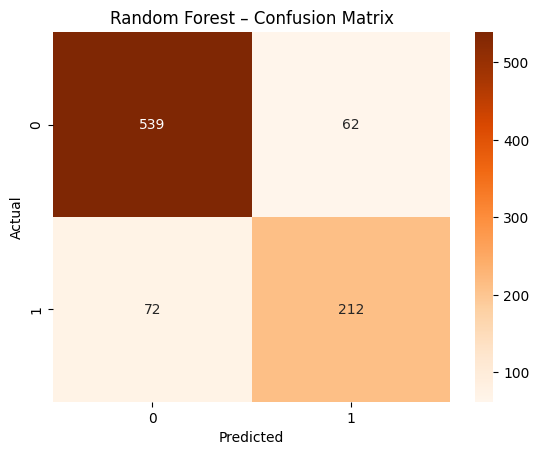

In [ ]:
# Random Forest – Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Random Forest – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
tn, fp, fn, tp = cm_rf.ravel()

print(f"""
Random Forest Confusion Matrix:
------------------------------
            Predicted
            0     1
Actual 0   {tn}    {fp}
Actual 1   {fn}    {tp}
""")


Random Forest Confusion Matrix:
------------------------------
            Predicted
            0     1
Actual 0   539    62
Actual 1   72    212



Random Forest ROC-AUC: 0.8953328958777625


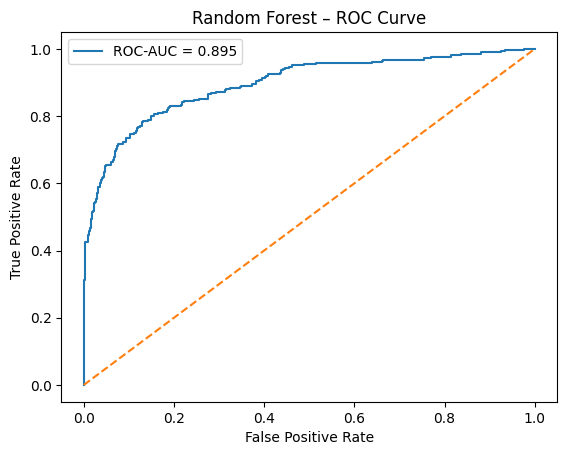

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
# Predicted probabilities
y_prob_rf = rf.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_rf:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest – ROC Curve")
plt.legend()
plt.show()


In [ ]:
# Feature Importance
importances_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importances_rf.head(10)

,Feature,Importance
6,Curricular units 1st sem (approved),0.217406
7,Curricular units 1st sem (grade),0.137094
222,Tuition fees up to date_1,0.100107
2,Age at enrollment,0.063301
5,Curricular units 1st sem (evaluations),0.060476
224,Scholarship holder_1,0.042937
221,Debtor_1,0.035951
4,Curricular units 1st sem (enrolled),0.026375
1,Admission grade,0.023995
223,Gender_1,0.022802


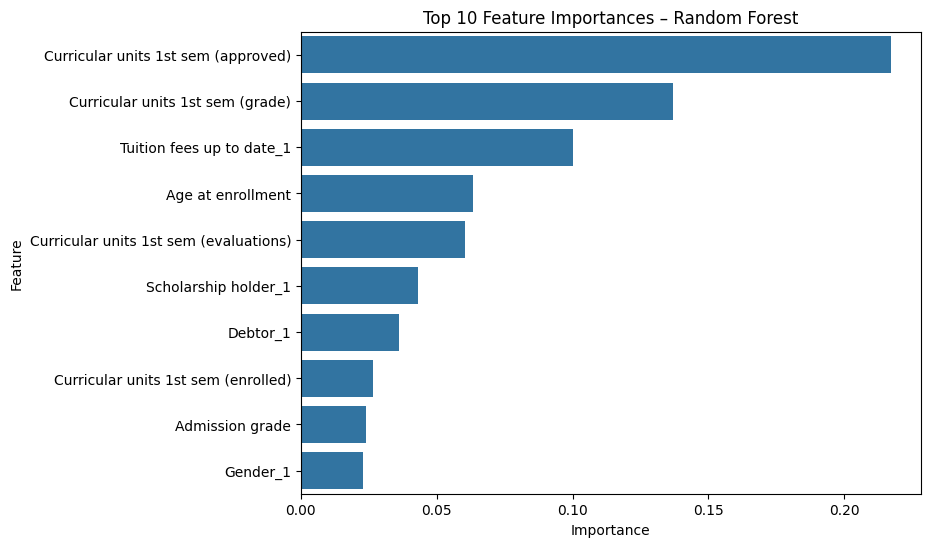

In [ ]:
# Feature Importance
plt.figure(figsize=(8,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importances_rf.head(10)
)
plt.title("Top 10 Feature Importances – Random Forest")
plt.show()

In [ ]:
# Save Random Forest results
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_rf)],
    "F1-score": [f1_score(y_test, y_pred_rf)]
})

rf_results.to_csv(
    f"{PROJECT_ROOT}/results/metrics/random_forest_results.csv",
    index=False
)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Parameter grid for XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'gamma': [0, 0.3, 0.5],
    'min_child_weight': [1, 5, 10]
}

# Base model
xgb = XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='logloss'
)

# Randomized Search
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=10,        # keep small for speed
    cv=3,
    scoring='f1',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Train
xgb_random.fit(X_train, y_train)

# Best model
xgb = xgb_random.best_estimator_

print("Best XGBoost Parameters:", xgb_random.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Parameters: {'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.6}


In [ ]:
cv_scores_xgb = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("XGBoost Mean CV F1:", cv_scores_xgb.mean())

XGBoost Mean CV F1: 0.7665332506873006


In [ ]:
# Evaluate XGBoost
y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89       601
           1       0.74      0.81      0.78       284

    accuracy                           0.85       885
   macro avg       0.83      0.84      0.83       885
weighted avg       0.85      0.85      0.85       885



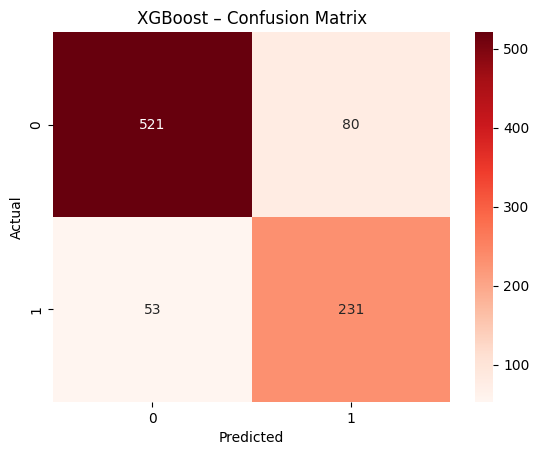

In [ ]:
# confusion matrix XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost – Confusion Matrix")
plt.show()

In [ ]:
tn, fp, fn, tp = cm_xgb.ravel()

print(f"""
XGBoost Confusion Matrix:
------------------------
            Predicted
            0     1
Actual 0   {tn}    {fp}
Actual 1   {fn}    {tp}
""")


XGBoost Confusion Matrix:
------------------------
            Predicted
            0     1
Actual 0   521    80
Actual 1   53    231



XGBoost ROC-AUC: 0.9123585104637811


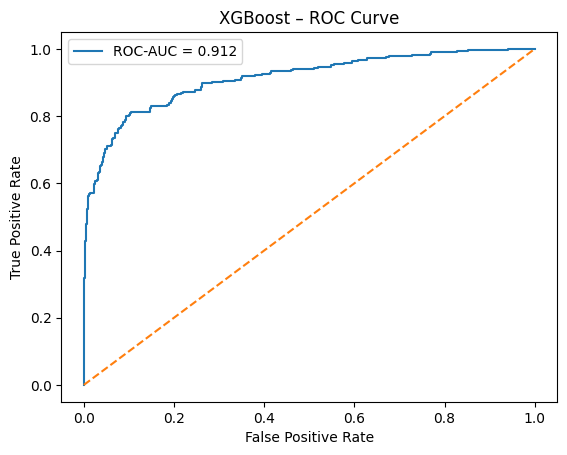

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost ROC-AUC:", roc_auc_xgb)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_xgb:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost – ROC Curve")
plt.legend()
plt.show()

In [ ]:
# Feature Importance
importances_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

importances_xgb.head(10)

,Feature,Importance
6,Curricular units 1st sem (approved),0.060588
222,Tuition fees up to date_1,0.053613
7,Curricular units 1st sem (grade),0.038648
224,Scholarship holder_1,0.027238
221,Debtor_1,0.026811
41,Course_171,0.018884
137,Father's qualification_34,0.018320
4,Curricular units 1st sem (enrolled),0.017114
2,Age at enrollment,0.016879
55,Course_9853,0.015406


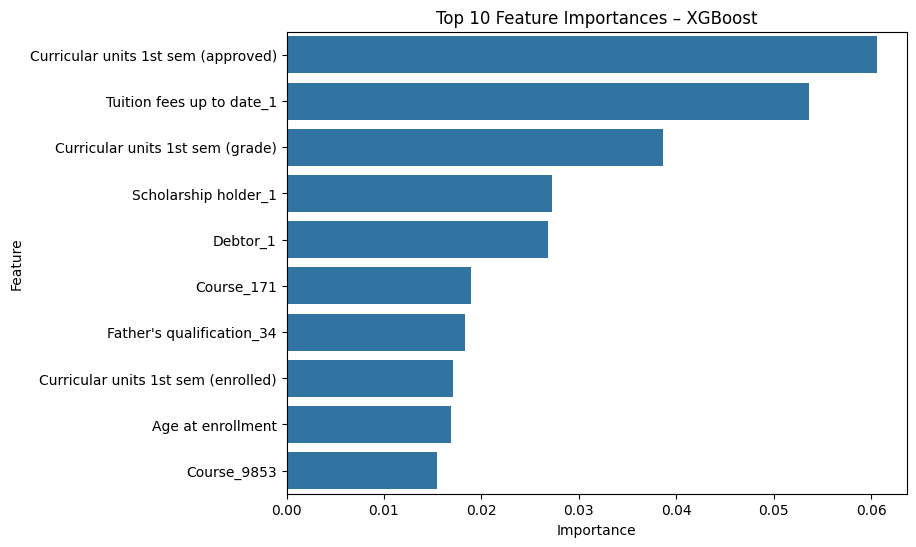

In [ ]:
# Feature Importance
plt.figure(figsize=(8,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importances_xgb.head(10)
)
plt.title("Top 10 Feature Importances – XGBoost")
plt.show()

In [ ]:
# Save XGBoost results
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_xgb)],
    "Precision": [precision_score(y_test, y_pred_xgb)],
    "Recall": [recall_score(y_test, y_pred_xgb)],
    "F1-score": [f1_score(y_test, y_pred_xgb)]
})

xgb_results.to_csv(
    f"{PROJECT_ROOT}/results/metrics/xgboost_results.csv",
    index=False
)

In [ ]:
# Overfitting Check
print("Random Forest Train Recall:", recall_score(y_train, rf.predict(X_train)))
print("Random Forest Test Recall :", recall_score(y_test, y_pred_rf))

print("XGBoost Train Recall:", recall_score(y_train, xgb.predict(X_train)))
print("XGBoost Test Recall :", recall_score(y_test, y_pred_xgb))

Random Forest Train Recall: 0.8258575197889182
Random Forest Test Recall : 0.7464788732394366
XGBoost Train Recall: 0.841688654353562
XGBoost Test Recall : 0.8133802816901409


In [ ]:
from sklearn.model_selection import cross_val_score
print("RF CV Mean:", cv_scores.mean())
print("RF CV Std :", cv_scores.std())

print("XGB CV Mean:", cv_scores_xgb.mean())
print("XGB CV Std :", cv_scores_xgb.std())

RF CV Mean: 0.7525795418326513
RF CV Std : 0.02144174264702701
XGB CV Mean: 0.7665332506873006
XGB CV Std : 0.018624079307617867
